# Exercise 9-1: Analyze time-series data

## Read the data

In [20]:
import pandas as pd
import seaborn as sns

data_dir = "../../data"

In [21]:
awards_df = pd.read_pickle(f'{data_dir}/pkl_files/awards_data_2010_2025.pkl')
awards_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187761 entries, 0 to 187760
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   awd_id                       187761 non-null  object 
 1   agcy_id                      187761 non-null  object 
 2   tran_type                    187761 non-null  object 
 3   awd_istr_txt                 187761 non-null  object 
 4   awd_titl_txt                 187761 non-null  object 
 5   cfda_num                     187367 non-null  object 
 6   org_code                     187761 non-null  object 
 7   po_phone                     121196 non-null  object 
 8   po_email                     187761 non-null  object 
 9   po_sign_block_name           187755 non-null  object 
 10  awd_eff_date                 187761 non-null  object 
 11  awd_exp_date                 187761 non-null  object 
 12  tot_intn_awd_amt             187761 non-null  float64
 13 

In [22]:
# We're going to count awards by date range, so for this exercise, we literally only need
# the awd_eff_date column as a datetime object.
awards_df['awd_eff_date'] = pd.to_datetime(awards_df['awd_eff_date'])
awards_df = awards_df[['awd_eff_date']]
awards_df.head()

,awd_eff_date
0,2010-01-01
1,2009-12-01
2,2010-09-01
3,2010-04-15
4,2010-09-01


In [23]:
# Add a column for awd_count
awards_df['awd_count'] = 1

In [24]:
# Summarize awd_count by awd_eff_date
awards_df = awards_df.groupby('awd_eff_date').agg({'awd_count': 'sum'}).reset_index()
awards_df.head()

,awd_eff_date,awd_count
0,2008-05-15,1
1,2008-05-31,1
2,2008-08-01,1
3,2008-09-01,1
4,2008-10-01,1


<Axes: >

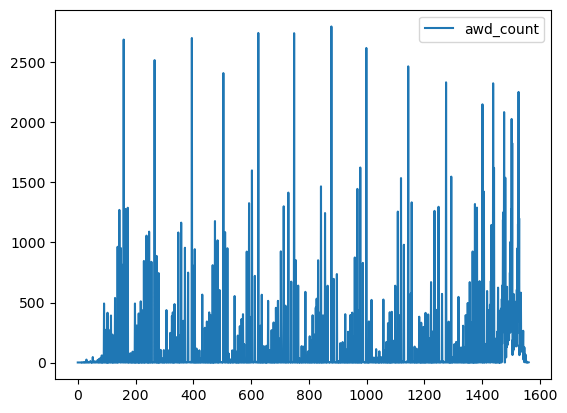

In [25]:
# Plot the data
awards_df.plot(y='awd_count')

## Generate date ranges

In [ ]:
# use the pd.date_range() method to generate a daterange for every other day in the year 2020
pd.date_range('01/01/2020','12/31/2020', freq='2D')

DatetimeIndex(['2020-01-01', '2020-01-03', '2020-01-05', '2020-01-07',
               '2020-01-09', '2020-01-11', '2020-01-13', '2020-01-15',
               '2020-01-17', '2020-01-19',
               ...
               '2020-12-12', '2020-12-14', '2020-12-16', '2020-12-18',
               '2020-12-20', '2020-12-22', '2020-12-24', '2020-12-26',
               '2020-12-28', '2020-12-30'],
              dtype='datetime64[ns]', length=183, freq='2D')

In [27]:
# generate a daterange for every 3 hours in 2020
pd.date_range('01/01/2020','12/31/2020', freq='3H')

DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 03:00:00',
               '2020-01-01 06:00:00', '2020-01-01 09:00:00',
               '2020-01-01 12:00:00', '2020-01-01 15:00:00',
               '2020-01-01 18:00:00', '2020-01-01 21:00:00',
               '2020-01-02 00:00:00', '2020-01-02 03:00:00',
               ...
               '2020-12-29 21:00:00', '2020-12-30 00:00:00',
               '2020-12-30 03:00:00', '2020-12-30 06:00:00',
               '2020-12-30 09:00:00', '2020-12-30 12:00:00',
               '2020-12-30 15:00:00', '2020-12-30 18:00:00',
               '2020-12-30 21:00:00', '2020-12-31 00:00:00'],
              dtype='datetime64[ns]', length=2921, freq='3H')

In [28]:
# generate a date range for every other Friday in 2020
pd.date_range('01/01/2020','12/31/2020', freq='2W-FRI')

DatetimeIndex(['2020-01-03', '2020-01-17', '2020-01-31', '2020-02-14',
               '2020-02-28', '2020-03-13', '2020-03-27', '2020-04-10',
               '2020-04-24', '2020-05-08', '2020-05-22', '2020-06-05',
               '2020-06-19', '2020-07-03', '2020-07-17', '2020-07-31',
               '2020-08-14', '2020-08-28', '2020-09-11', '2020-09-25',
               '2020-10-09', '2020-10-23', '2020-11-06', '2020-11-20',
               '2020-12-04', '2020-12-18'],
              dtype='datetime64[ns]', freq='2W-FRI')

## Reindex the data

In [29]:
# Set the 'awd_eff_date' column as the index for the DataFrame
awards_df.set_index('awd_eff_date', inplace=True)
awards_df.head()

,awd_count
awd_eff_date,
2008-05-15,1
2008-05-31,1
2008-08-01,1
2008-09-01,1
2008-10-01,1


In [30]:
# reindex the data so the data contains only Fridays
awd_data_fridays_df = awards_df.reindex(pd.date_range('01/01/2020','12/31/2024', freq='W-FRI'))
awd_data_fridays_df.head()

,awd_count
2020-01-03,1.0
2020-01-10,2.0
2020-01-17,1.0
2020-01-24,1.0
2020-01-31,1.0


<Axes: title={'center': 'Awards by Friday'}>

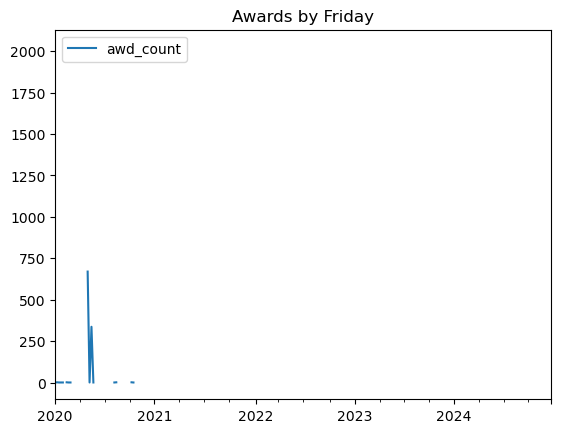

In [31]:
# plot the data to see the effect of subtracting everything except Fridays
awd_data_fridays_df.plot(y='awd_count', title='Awards by Friday')

## Resample the data

In [32]:
# The resample() method is used to change the frequency of the data. 
# Here, you will resample the data to a monthly frequency ('M') and calculate the mean of 'awd_count' for each month.
resampled_awards_df = awards_df.resample(rule='M').mean()

<Axes: xlabel='awd_eff_date'>

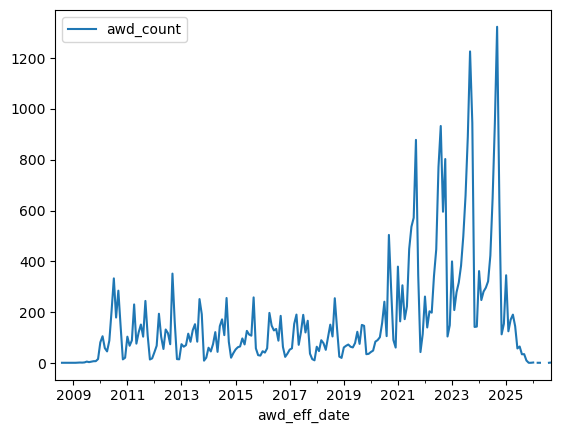

In [33]:
# Plot the result
resampled_awards_df.plot(y='awd_count')

## Compute a rolling window

In [34]:
# The rolling() method provides a moving window view over the data, allowing us to calculate statistics (e.g., mean) over a specified window size.
# compute a 2 week rolling window
awds_rolling_df = awards_df[['awd_count']].rolling(window=14, min_periods=1).mean()
awds_rolling_df.head()

,awd_count
awd_eff_date,
2008-05-15,1.0
2008-05-31,1.0
2008-08-01,1.0
2008-09-01,1.0
2008-10-01,1.0


<Axes: xlabel='awd_eff_date'>

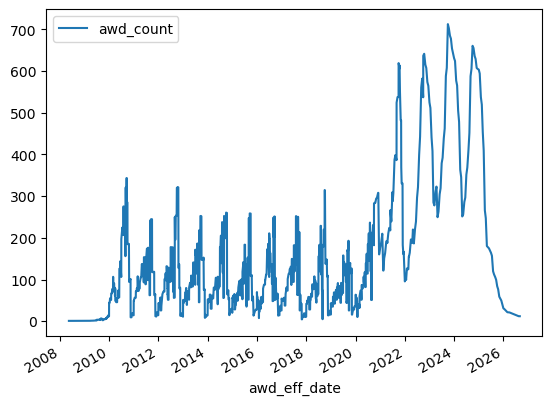

In [35]:
# Plot the result
awds_rolling_df.plot()